# NPS · produto e serviços · 2025 e 2026
Base: exportação das campanhas de NPS da Track, um arquivo por grupo e por ano (produto AgriManager,
produto myFarm e serviços), de janeiro de 2025 a setembro de 2026. A pergunta de negócio: **como está
a percepção do cliente em cada produto e serviço, se 2026 está melhor ou pior que 2025, o que puxa a
nota pra baixo e se o ano vai fechar acima de 2025**, que é a meta. Leitor final: diretoria.

In [1]:
import json, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from temas_comentarios import TEMAS, MOTIVOS, IGNORAR
from motivo_real import motivo_real, do_comentario, do_marcado, MARCADO, SEM

pd.set_option("display.max_columns", None)

In [2]:
GRUPOS = ["Produto AgriManager", "Produto myFarm", "Serviços"]
COR = {"Produto AgriManager": "#2a78d6", "Produto myFarm": "#eb6834", "Serviços": "#1baf7a"}
COR_SECUNDARIA = "#94A3B8"
plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 110, "font.size": 12,
    "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

## Os arquivos foram lidos certo?
Os CSVs vêm da Track com `;` e acentuação em latin-1. Conferir tamanho e contas de cada arquivo.

In [3]:
ARQ = [("Produto AgriManager", 2025, "NPS AGM 2025.csv"), ("Produto AgriManager", 2026, "NPS produto - AGM.csv"),
       ("Produto myFarm", 2025, "NPS myFarm 2025.csv"), ("Produto myFarm", 2026, "NPS produto - myFarm.csv"),
       ("Serviços", 2025, "NPS Serviço 2025.csv"), ("Serviços", 2026, "NPS serviços.csv")]
bruto = {(g, a): pd.read_csv(f, sep=";", encoding="latin-1", dtype=str) for g, a, f in ARQ}
pd.DataFrame({f"{g} {a}": [d.shape[0], d.shape[1], d["Nome da Conta"].nunique()] for (g, a), d in bruto.items()},
             index=["respostas", "colunas", "contas"]).T

,respostas,colunas,contas
Produto AgriManager 2025,343,30,147
Produto AgriManager 2026,172,31,94
Produto myFarm 2025,359,31,187
Produto myFarm 2026,281,31,151
Serviços 2025,81,40,55
Serviços 2026,56,45,40


In [4]:
bruto[("Produto AgriManager", 2026)][["Data/Hora da Opinião", "Nome da Conta", "Nota", "Comentário", "Categoria"]].head(3)

,Data/Hora da Opinião,Nome da Conta,Nota,Comentário,Categoria
0,17/09/26 17:01,FERNANDO CAVALHEIRO MACHADO,10,. ## Justificativas ## Outro,Siagri AgriManager
1,14/09/26 08:40,GRUPO CATELAN,4,## Justificativas ## Falhas durante o uso do ERP,"Siagri AgriManager, Falhas durante o uso do pr..."
2,11/09/26 11:39,AGROPECUARIA DUMONCEL,10,## Justificativas ## Aderência do ERP ao seu N...,"Siagri AgriManager, Aderência do produto ao se..."


**Leitura:** acentos legíveis, uma resposta por linha nos seis arquivos. Diferenças que a
padronização abaixo resolve: no AgriManager o motivo marcado pelo cliente vem **dentro** do
comentário, depois de `## Justificativas ##`, sem vírgula entre as opções; no myFarm não existe
motivo marcado, só a categoria da tratativa; nos serviços o motivo vem na coluna `Justificativas`.
Os arquivos de 2025 têm alguns nomes de coluna e de motivo diferentes dos de 2026 (a UF vem em
`Estado`, e serviços usa rótulos como "Execução do Projeto/Treinamento").

## Juntar as campanhas numa base só
Uma linha por resposta, com grupo, ano, campanha, mês, nota, classe (detrator 0 a 6, neutro 7 e 8,
promotor 9 e 10), comentário, motivos e o cliente com nome padronizado.

In [5]:
OPCOES_AGM = sorted([k for k in MOTIVOS if k in (
    "Aderência do ERP ao seu Negócio", "Aderência do ERP ao seu dia a dia", "Falhas durante o uso do ERP",
    "Uso/navegação das funcionalidades do ERP", "Experiência com o Suporte Aliare", "Atendimento do Suporte Aliare",
    "Recursos do Produto", "Atualização de versão do ERP", "Falta de Contato",
    "Experiência com outras áreas Aliare", "Outro")], key=len, reverse=True)

def motivos_agm(txt):
    parte = str(txt).split("## Justificativas ##")[1] if "## Justificativas ##" in str(txt) else ""
    achados = []
    for op in OPCOES_AGM:
        if op in parte:
            achados.append(op); parte = parte.replace(op, " ")
    return achados

def lista(txt):
    return [p.strip() for p in str(txt).split(",") if p.strip() and str(txt) != "nan"]

def temas_motivo(itens):
    return sorted({MOTIVOS[i] for i in itens if i in MOTIVOS})

def chave_cliente(nome, servico):
    n = str(nome).strip()
    if servico:
        n = re.sub(r"\s*-\s*[^-]*-\s*[A-Z]{2}\s*$", "", n)
        n = re.sub(r"\s+-\s+[A-Z]{2}\s*$", "", n)
    n = unicodedata.normalize("NFKD", n).encode("ascii", "ignore").decode().upper()
    return re.sub(r"\s+", " ", n).strip(" -")

CAMP = {
    "Pesquisa Siagri AgriManager": "Produto AgriManager",
    "Pesquisa MyFarm": "Produto myFarm",
    "Pesquisa CeS MyFarm (Hunter) - Projetos de Implantação": "Implantação myFarm",
    "Pesquisa CeS AGM (Hunter) - Projetos de Implantação": "Implantação AgriManager",
    "Pesquisa CeS AGM (Farmer) - Apoio Técnico e Treinamentos": "Apoio técnico e treinamento AgriManager",
    "Pesquisa CeS MyFarm (Farmer) - Apoio Técnico e Treinamentos": "Apoio técnico e treinamento myFarm",
    "Pesquisa CeS AgroScore Siagri AgriManager": "Monitoria AgroScore AgriManager",
}
LINHA = {"MYFARM": "myFarm", "SIAGRI AGRIMANAGER": "AgriManager"}

In [6]:
partes = []
for (grupo, ano), d in bruto.items():
    serv = grupo == "Serviços"
    x = pd.DataFrame({
        "id": d["#"], "grupo": grupo, "ano": ano, "campanha": d["Campanha"].map(CAMP),
        "data": pd.to_datetime(d["Data/Hora da Opinião"], format="%d/%m/%y %H:%M"),
        "nota": d["Nota"].astype(int),
        "nota_anterior": pd.to_numeric(d["Nota Anterior"], errors="coerce"),
        "conta": d["Nome da Conta"].str.strip(),
        "respondente": d["Nome"].str.strip().str.title(),
        "uf": d["Estado"] if "Estado" in d.columns else d["UF"],
        "status": d["Status"],
    })
    if grupo == "Produto AgriManager":
        x["comentario"] = d["Comentário"].str.split("## Justificativas ##").str[0].str.strip(" .")
        cliente = d["Comentário"].map(motivos_agm)
    elif serv:
        x["comentario"] = d["Comentário"].str.strip()
        cliente = d["Justificativas"].map(lista)
    else:
        x["comentario"] = d["Comentário"].str.strip()
        cliente = pd.Series([[]] * len(d), index=d.index)
    cs = d["Categoria"].map(lista).map(lambda l: [i for i in l if i not in IGNORAR])
    x["motivos"] = [temas_motivo(a + b) for a, b in zip(cliente, cs)]
    x["marcado_cliente"] = list(cliente)
    x["marcados"] = [list(dict.fromkeys(a + b)) for a, b in zip(cliente, cs)]
    x["linha"] = d["Linha Produto"].map(LINHA) if serv else ("AgriManager" if grupo == "Produto AgriManager" else "myFarm")
    x["cliente"] = [chave_cliente(n, serv) for n in d["Nome da Conta"]]
    partes.append(x)

nps = pd.concat(partes, ignore_index=True)
nps["comentario"] = nps["comentario"].where(nps["comentario"].str.len() > 3)
nps["classe"] = pd.cut(nps["nota"], [-1, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"]).astype(str)
nps["mes"] = nps["data"].dt.to_period("M")
nps["temas_coment"] = [TEMAS.get(i, ["Sem conteúdo"] if isinstance(c, str) else []) for i, c in zip(nps["id"], nps["comentario"])]
nps["tem_texto"] = nps["comentario"].notna() & nps["temas_coment"].map(lambda t: t != ["Sem conteúdo"])
nps["motivo_real"] = [motivo_real(i, t, m, c, g) for i, t, m, c, g in zip(nps["id"], nps["temas_coment"], nps["marcados"], nps["classe"], nps["grupo"])]
nps[["grupo", "ano", "campanha", "linha", "mes", "nota", "classe", "cliente", "marcados", "temas_coment", "motivo_real"]].sample(6, random_state=1)

,grupo,ano,campanha,linha,mes,nota,classe,cliente,marcados,temas_coment,motivo_real
1209,Serviços,2025,Apoio técnico e treinamento AgriManager,AgriManager,2025-06,10,Promotor,3TENTOS,"[Planejamento e Organização, Comunicação Clara...",[Elogio ao atendimento],Atendimento do consultor
646,Produto myFarm,2025,Produto myFarm,myFarm,2025-08,10,Promotor,RODOLFO CAVALCANTE PINHEIRO,[],[],Sem motivo informado
60,Produto AgriManager,2025,Produto AgriManager,AgriManager,2025-10,8,Neutro,AGROPECUARIA BONANZA,"[Uso/navegação das funcionalidades do ERP, Rec...",[],Recursos e relatórios
985,Produto myFarm,2026,Produto myFarm,myFarm,2026-05,1,Detrator,AVELINO NERI BOCOLLI - AGRO ALIANCA LTDA,[],[],Sem motivo informado
791,Produto myFarm,2025,Produto myFarm,myFarm,2025-03,10,Promotor,CHRISTIANE TOLEDO TENORIO LESSA,[],[],Sem motivo informado
1048,Produto myFarm,2026,Produto myFarm,myFarm,2026-03,10,Promotor,LORIVAL DE BORTOLO,[],[],Sem motivo informado


In [7]:
pd.DataFrame({"respostas": nps.groupby(["grupo", "ano"]).size(),
              "sem campanha mapeada": nps[nps["campanha"].isna()].groupby(["grupo", "ano"]).size(),
              "sem linha": nps[nps["linha"].isna()].groupby(["grupo", "ano"]).size(),
              "com motivo": nps[nps["motivos"].str.len() > 0].groupby(["grupo", "ano"]).size(),
              "com comentário": nps[nps["comentario"].notna()].groupby(["grupo", "ano"]).size()}).fillna(0).astype(int)

respostas  sem campanha mapeada  sem linha  \
grupo               ano                                                
Produto AgriManager 2025        343                     0          0   
                    2026        172                     0          0   
Produto myFarm      2025        359                     0          0   
                    2026        281                     0          0   
Serviços            2025         81                     0          2   
                    2026         56                     0          0   

                          com motivo  com comentário  
grupo               ano                               
Produto AgriManager 2025         291              48  
                    2026         169              26  
Produto myFarm      2025          11              31  
                    2026          17              28  
Serviços            2025          74              66  
                    2026          53              29

In [8]:
sem = nps[nps["temas_coment"].map(lambda t: t == ["Sem conteúdo"])]
sem[["ano", "grupo", "nota", "comentario"]]

,ano,grupo,nota,comentario
202,2025,Produto AgriManager,9,nada a declarar
351,2026,Produto AgriManager,7,bidwfidgfuidf
474,2026,Produto AgriManager,7,hdbdhbfkbiuf
801,2025,Produto myFarm,10,JBHKJB
971,2026,Produto myFarm,10,BFSHBW
1086,2026,Produto myFarm,10,lllll
1161,2025,Serviços,10,Sem comentários
1272,2026,Serviços,10,SEM COMENTÁRIO
1277,2026,Serviços,3,SEM COMENTÁRIO


**Leitura:** as seis bases juntas somam 1.292 respostas, todas com campanha e produto
identificados (duas respostas de serviço de 2025 vieram sem linha de produto e ficam fora só do
filtro por produto). O motivo existe pra quase todo AgriManager e serviços, mas **quase nunca pro
myFarm**: 11 de 359 respostas em 2025 e 17 de 281 em 2026. No myFarm, o "porquê" da nota depende do
comentário escrito, que não é obrigatório. Os comentários sem conteúdo (texto de teste, "sem
comentário") estão listados acima e ficam fora da leitura de assunto.

# Parte 1 · 2026 até setembro
As perguntas desta parte olham só 2026 (janeiro a setembro).

In [9]:
n26 = nps[nps["ano"] == 2026].copy()
n25 = nps[nps["ano"] == 2025].copy()
len(n26), len(n25)

(509, 783)

## Qual é o NPS de cada produto e serviço no acumulado de 2026?
NPS = % de promotores menos % de detratores. Sempre com o número de respostas ao lado.

In [10]:
def calc_nps(g):
    n = len(g)
    return pd.Series({"respostas": n,
                      "promotores %": round(100 * (g["classe"] == "Promotor").mean(), 1),
                      "neutros %": round(100 * (g["classe"] == "Neutro").mean(), 1),
                      "detratores %": round(100 * (g["classe"] == "Detrator").mean(), 1),
                      "NPS": round(100 * ((g["classe"] == "Promotor").mean() - (g["classe"] == "Detrator").mean()), 1)})

n26.groupby("grupo")[["classe"]].apply(calc_nps)

,respostas,promotores %,neutros %,detratores %,NPS
grupo,,,,,
Produto AgriManager,172.0,40.1,21.5,38.4,1.7
Produto myFarm,281.0,66.5,8.2,25.3,41.3
Serviços,56.0,67.9,23.2,8.9,58.9


In [11]:
n26.groupby(["grupo", "campanha"])[["classe"]].apply(calc_nps).sort_values("respostas", ascending=False)

respostas  \
grupo               campanha                                             
Produto myFarm      Produto myFarm                               281.0   
Produto AgriManager Produto AgriManager                          172.0   
Serviços            Implantação myFarm                            26.0   
                    Apoio técnico e treinamento AgriManager       18.0   
                    Apoio técnico e treinamento myFarm             9.0   
                    Monitoria AgroScore AgriManager                3.0   

                                                             promotores %  \
grupo               campanha                                                
Produto myFarm      Produto myFarm                                   66.5   
Produto AgriManager Produto AgriManager                              40.1   
Serviços            Implantação myFarm                               65.4   
                    Apoio técnico e treinamento AgriManager          66.7   
                    Apoio técnico e treinamento myFarm               66.7   
                    Monitoria AgroScore AgriManager                 100.0   

                                                             neutros %  \
grupo               campanha                                             
Produto myFarm      Produto myFarm                                 8.2   
Produto AgriManager Produto AgriManager                           21.5   
Serviços            Implantação myFarm                            19.2   
                    Apoio técnico e treinamento AgriManager       27.8   
                    Apoio técnico e treinamento myFarm            33.3   
                    Monitoria AgroScore AgriManager                0.0   

                                                             detratores %  \
grupo               campanha                                                
Produto myFarm      Produto myFarm                                   25.3   
Produto AgriManager Produto AgriManager                              38.4   
Serviços            Implantação myFarm                               15.4   
                    Apoio técnico e treinamento AgriManager           5.6   
                    Apoio técnico e treinamento myFarm                0.0   
                    Monitoria AgroScore AgriManager                   0.0   

                                                               NPS  
grupo               campanha                                        
Produto myFarm      Produto myFarm                            41.3  
Produto AgriManager Produto AgriManager                        1.7  
Serviços            Implantação myFarm                        50.0  
                    Apoio técnico e treinamento AgriManager   61.1  
                    Apoio técnico e treinamento myFarm        66.7  
                    Monitoria AgroScore AgriManager          100.0

**Resultado:** três realidades diferentes em 2026. O AgriManager empata promotor e detrator
(NPS perto de zero, com 4 em cada 10 respostas de detrator). O myFarm tem 2 em cada 3 respostas de
promotor, mas 1 em 4 de detrator, quase sem neutro: o cliente myFarm ou gosta ou não gosta. Serviços
é o ponto mais alto, e isso vale pras três campanhas com base razoável (implantação myFarm, apoio
técnico AgriManager e myFarm). A monitoria AgroScore tem 3 respostas, não dá pra ler sozinha. A
margem de erro do NPS anual fica entre 5 e 9 pontos, então a distância entre os três é real.
Atenção: em serviços a Track mostra 61 respostas e NPS 62; o arquivo exportado tem 56 e dá 59.
Faltam 5 promotores na exportação, a reexportação corrige.

## Como o NPS de cada mês se comportou?
Linha por produto e serviço, só com as respostas de cada mês. O número de respostas vai junto,
porque mês com poucas respostas balança muito.

In [12]:
mensal = n26.groupby(["grupo", "mes"])[["classe"]].apply(calc_nps).reset_index()
mensal.pivot(index="mes", columns="grupo", values=["NPS", "respostas"])

NPS                                   respostas  \
grupo   Produto AgriManager Produto myFarm Serviços Produto AgriManager   
mes                                                                       
2026-01                 0.0           61.4    100.0                30.0   
2026-02                 8.7           37.9      NaN                23.0   
2026-03               -12.5           54.1     54.5                16.0   
2026-04                 3.1           39.5     55.6                32.0   
2026-05                -5.6           40.6    100.0                18.0   
2026-06                 7.1           25.0     55.6                14.0   
2026-07                -5.9           19.2     91.7                17.0   
2026-08                 6.7           44.0      0.0                15.0   
2026-09                28.6           31.8    -33.3                 7.0   

                                 
grupo   Produto myFarm Serviços  
mes                              
2026-01           44.0      1.0  
2026-02           29.0      NaN  
2026-03           37.0     11.0  
2026-04           38.0     18.0  
2026-05           32.0      1.0  
2026-06           28.0      9.0  
2026-07           26.0     12.0  
2026-08           25.0      1.0  
2026-09           22.0      3.0

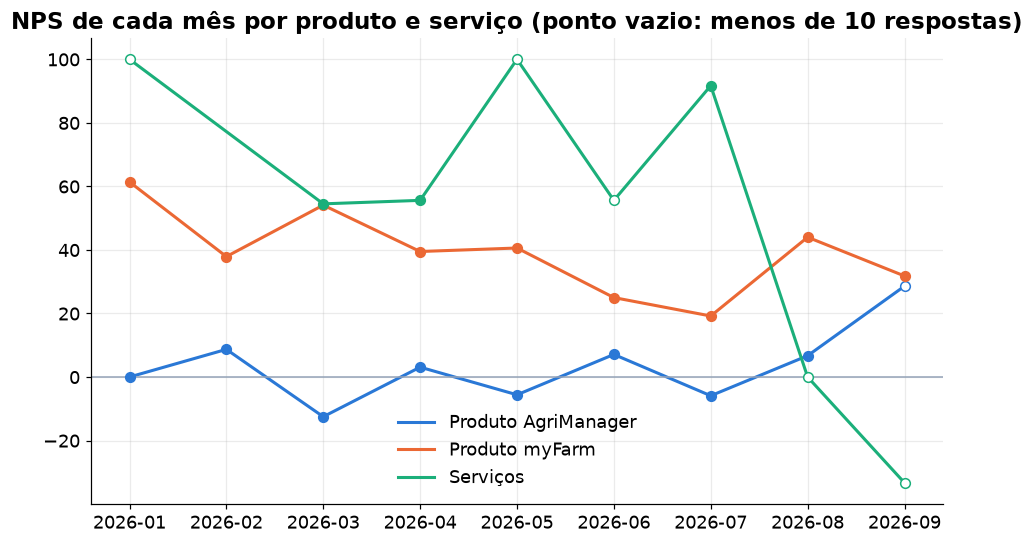

In [13]:
fig, ax = plt.subplots()
for g, d in mensal.groupby("grupo"):
    ok = d["respostas"] >= 10
    ax.plot(d["mes"].astype(str), d["NPS"], color=COR[g], lw=2, label=g)
    ax.scatter(d.loc[ok, "mes"].astype(str), d.loc[ok, "NPS"], color=COR[g], s=40, zorder=3)
    ax.scatter(d.loc[~ok, "mes"].astype(str), d.loc[~ok, "NPS"], facecolor="white", edgecolor=COR[g], s=40, zorder=3)
ax.axhline(0, color=COR_SECUNDARIA, lw=1)
ax.set_title("NPS de cada mês por produto e serviço (ponto vazio: menos de 10 respostas)")
ax.legend(frameon=False); plt.show()

**Resultado:** o NPS isolado de cada mês só se lê sem susto no myFarm (22 a 44 respostas por
mês). No AgriManager, o salto de setembro (7 respostas) é ruído, e serviços tem meses com 1 a 3
respostas: o −33 de setembro em serviços são 3 respostas, não uma queda. Por isso a leitura
principal passa a ser o acumulado do ano, logo abaixo.

## Como o NPS acumulado do ano andou mês a mês?
É a conta que a Track mostra no painel: todas as respostas de janeiro até o fim de cada mês.
Ao lado, quanto o acumulado subiu ou desceu em relação ao mês anterior.

In [14]:
def acumulado(df):
    linhas = []
    for (g, a), d in df.groupby(["grupo", "ano"]):
        ultimo = d["data"].dt.month.max()
        for m in range(1, ultimo + 1):
            c = calc_nps(d[d["data"].dt.month <= m])
            linhas.append({"grupo": g, "ano": a, "mes": m, "NPS": c["NPS"], "respostas": c["respostas"]})
    return pd.DataFrame(linhas)

acum = acumulado(nps)
a26 = acum[acum["ano"] == 2026].pivot(index="mes", columns="grupo", values="NPS")
a26.join(a26.diff().round(1).add_suffix(" · variação"))

grupo,Produto AgriManager,Produto myFarm,Serviços,Produto AgriManager · variação,Produto myFarm · variação,Serviços · variação
mes,,,,,,
1,0.0,61.4,100.0,NaN,NaN,NaN
2,3.8,52.1,100.0,3.8,-9.3,0.0
3,0.0,52.7,58.3,-3.8,0.6,-41.7
4,1.0,49.3,56.7,1.0,-3.4,-1.6
5,0.0,47.8,58.1,-1.0,-1.5,1.4
6,0.8,44.7,57.5,0.8,-3.1,-0.6
7,0.0,41.9,65.4,-0.8,-2.8,7.9
8,0.6,42.1,64.2,0.6,0.2,-1.2
9,1.7,41.3,58.9,1.1,-0.8,-5.3


**Resultado:** o acumulado do ano é a conta que a Track mostra. Nele, o AgriManager fica
entre 0 e 4 o ano inteiro, sem tendência. O **myFarm desce quase todo mês**, de 61 em janeiro pra
41 em setembro; em oito meses, só março e agosto tiveram variação positiva, e pequena. Serviços
começa com 1 resposta em janeiro, então o tombo de março é efeito de base pequena; de março em
diante fica entre 57 e 65.

## Por trimestre, a tendência se sustenta?
Agrupar em trimestres dá base maior a cada ponto e mostra se a queda ou a subida é real.

In [15]:
n26["tri"] = "T" + n26["data"].dt.quarter.astype(str)
n26.groupby(["grupo", "tri"])[["classe"]].apply(calc_nps)[["respostas", "NPS"]].unstack("tri")

respostas               NPS            
tri                        T1    T2    T3    T1    T2    T3
grupo                                                      
Produto AgriManager      69.0  64.0  39.0   0.0   1.6   5.1
Produto myFarm          110.0  98.0  73.0  52.7  35.7  31.5
Serviços                 12.0  28.0  16.0  58.3  57.1  62.5

**Resultado:** no trimestre a tendência aparece limpa. O **myFarm caiu de 53 pra 36 e pra 32**,
porque os promotores foram de 74% pra 60% e os detratores de 21% pra 29%. O AgriManager ficou parado
entre 0 e 5. Serviços manteve perto de 60 nos três trimestres.

## Que motivos aparecem entre os detratores de cada produto?
Taxa sobre as respostas de detrator **que têm motivo**. Uma resposta pode ter mais de um motivo.

In [16]:
det = n26[(n26["classe"] == "Detrator") & (n26["motivos"].str.len() > 0)].explode("motivos")
base = n26[(n26["classe"] == "Detrator") & (n26["motivos"].str.len() > 0)].groupby("grupo").size()
tab = det.groupby(["grupo", "motivos"]).size().unstack("grupo").fillna(0).astype(int)
(tab / base * 100).round(0).assign(**{f"n {g}": tab[g] for g in tab.columns}).sort_values("Produto AgriManager", ascending=False)

grupo,Produto AgriManager,Produto myFarm,Serviços,n Produto AgriManager,n Produto myFarm,n Serviços
motivos,,,,,,
Falhas e estabilidade,59.0,27.0,0.0,39,3,0
Recursos do produto,53.0,36.0,20.0,35,4,1
Suporte,36.0,0.0,0.0,24,0,0
Relacionamento e outras áreas,32.0,0.0,20.0,21,0,1
Outro,32.0,0.0,60.0,21,0,3
Usabilidade,6.0,73.0,0.0,4,8,0
Custo x benefício,2.0,0.0,0.0,1,0,0
Comunicação,0.0,0.0,20.0,0,0,1
Planejamento e execução do projeto,0.0,0.0,60.0,0,0,3


In [17]:
base.to_frame("detratores com motivo").join(n26[n26["classe"] == "Detrator"].groupby("grupo").size().to_frame("detratores"))

,detratores com motivo,detratores
grupo,,
Produto AgriManager,66,66
Produto myFarm,11,71
Serviços,5,5


**Resultado:** no AgriManager, o detrator aponta **falhas e estabilidade** (6 em cada 10) e
**recursos do produto** (5 em cada 10), seguidos de suporte. Esses motivos quase não aparecem entre
promotores, que citam **aderência ao negócio**: o sistema atende o processo, o que incomoda é o erro
e o que falta. A pesquisa pode mostrar opções diferentes conforme a nota, então isso descreve o que
cada grupo marca, não prova causa. No myFarm, só 11 dos 71 detratores têm motivo, e usabilidade
lidera; é base pequena demais pra ranking, o comentário diz mais (abaixo).

## Do que falam os comentários escritos?
Cada comentário foi lido e recebeu um ou mais assuntos (o de dentro do texto, não o marcado).
Comentário de teste ("hdbdhbfkbiuf", "SEM COMENTÁRIO") fica de fora.

In [18]:
com = n26[n26["comentario"].notna()].explode("temas_coment")
com = com[com["temas_coment"] != "Sem conteúdo"]
com.groupby(["temas_coment", "grupo"]).size().unstack("grupo").fillna(0).astype(int).sort_values("Produto myFarm", ascending=False)

grupo,Produto AgriManager,Produto myFarm,Serviços
temas_coment,,,
Lentidão e travamento,2,11,1
Elogio ao produto,2,6,0
Relatórios e recursos,6,6,1
Usabilidade e complexidade,6,4,0
Falhas e erros de versão,6,3,1
Suporte,2,2,0
Evolução do produto,3,2,1
Avaliação genérica,2,1,0
Aderência ao negócio,0,0,2


In [19]:
com[com["classe"] == "Detrator"].groupby(["grupo", "temas_coment"]).size().sort_values(ascending=False).head(12).to_frame("detratores")

detratores
grupo               temas_coment                          
Produto myFarm      Lentidão e travamento               10
Produto AgriManager Usabilidade e complexidade           5
                    Falhas e erros de versão             4
                    Relatórios e recursos                3
Produto myFarm      Relatórios e recursos                3
                    Usabilidade e complexidade           3
Produto AgriManager Suporte                              2
                    Evolução do produto                  2
Produto myFarm      Evolução do produto                  2
                    Suporte                              2
                    Falhas e erros de versão             2
Produto AgriManager Avaliação genérica                   1

**Resultado:** o comentário confirma e completa. No myFarm, **lentidão e travamento** é o assunto
de 10 comentários de detrator, bem à frente de qualquer outro: é a queixa concreta que a categoria
"usabilidade" esconde. No AgriManager, o texto fala de sistema complexo, erro depois de atualização
de versão e falta de recurso (custos, fiscal, relatórios). Em serviços, 18 comentários elogiam o
consultor pelo nome; a crítica fica na implantação (horas vendidas, prazo longo, troca de
consultor), não na pessoa.

## O detrator recebeu retorno?
Status da tratativa de cada resposta de detrator em 2026.

In [20]:
st = n26[n26["classe"] == "Detrator"].groupby(["grupo", "status"]).size().unstack("grupo").fillna(0).astype(int)
st.assign(total=st.sum(axis=1)).sort_values("total", ascending=False)

grupo,Produto AgriManager,Produto myFarm,Serviços,total
status,,,,
Encerrado sem sucesso nos contatos,23,23,0,46
Pendente Atuacao,18,19,2,39
Esclarecimentos efetuados,11,7,1,19
Pendente Atuacao Siagri,9,2,0,11
Nao Satisfeito com os esclarecimentos,3,6,0,9
Acoes em andamento,1,4,0,5
Resolvido Satisfeito,0,5,0,5
Resposta sem relação com a pesquisa,0,2,1,3
Nenhum,0,2,1,3


**Resultado:** pelo status gravado na Track, dos 142 detratores de 2026 só 24 aparecem como
resolvidos ou esclarecidos, 46 foram encerrados sem conseguir contato e 51 aparecem como pendentes,
espalhados por todos os meses desde janeiro. Os pendentes não refletem o trabalho feito: veja o ajuste
logo abaixo.

**Ajuste confirmado pelo Julio em 29/09/2026:** os detratores de 2026 que aparecem como
pendentes na Track (atuação interna, atuação do time de produto ou aguardando cliente) já foram
tratados pelo CS; a Track não atualizou o status dos loops. Na apresentação eles contam como
tratados. A coluna `status` continua com o valor original da Track; a apresentação usa
`status_painel`.

In [21]:
PENDENTES = ["Pendente Atuacao", "Pendente Atuacao Siagri", "Pendente Aguardando Cliente"]
nps["status_painel"] = np.where((nps["ano"] == 2026) & nps["status"].isin(PENDENTES), "Tratado pelo CS (loop sem atualizar na Track)", nps["status"])
n26["status_painel"] = nps.loc[n26.index, "status_painel"]
TRATADO = ["Resolvido Satisfeito", "Esclarecimentos efetuados", "Nao Satisfeito com os esclarecimentos", "Resolvido Insatisfeito",
           "Tratado pelo CS (loop sem atualizar na Track)"]
dt = n26[n26["classe"] == "Detrator"]
pd.DataFrame({"tratados pelo CS": dt[dt["status_painel"].isin(TRATADO)].groupby("grupo").size(),
              "cliente não atendeu o contato": dt[dt["status_painel"] == "Encerrado sem sucesso nos contatos"].groupby("grupo").size(),
              "em andamento": dt[dt["status_painel"] == "Acoes em andamento"].groupby("grupo").size(),
              "detratores": dt.groupby("grupo").size()}).fillna(0).astype(int)

,tratados pelo CS,cliente não atendeu o contato,em andamento,detratores
grupo,,,,
Produto AgriManager,42,23,1,66
Produto myFarm,40,23,4,71
Serviços,3,0,0,5


**Resultado:** com a confirmação de que os pendentes já foram tratados, 85 dos 142 detratores
de 2026 aparecem como tratados pelo CS. O que sobra é, principalmente, contato que não aconteceu: em
46 casos o cliente não atendeu às tentativas do CS. É o desafio de trazer o cliente para a conversa.
Para a Track bater com a apresentação, os status dos loops precisam ser atualizados na plataforma.

## Quem respondeu mais de uma vez em 2026: a nota subiu ou caiu?
Por cliente e grupo, compara a primeira e a última resposta do ano. Só entra quem tem pelo menos
duas respostas em datas diferentes.

In [22]:
ordem = n26.sort_values("data")
evo = ordem.groupby(["grupo", "cliente"]).agg(respostas=("nota", "size"), primeira=("nota", "first"),
                                               ultima=("nota", "last"), media=("nota", "mean"),
                                               dias=("data", lambda s: (s.max() - s.min()).days))
evo = evo[(evo["respostas"] >= 2) & (evo["dias"] > 0)]
evo["movimento"] = pd.cut(evo["ultima"] - evo["primeira"], [-11, -2, 1, 11], labels=["Caiu", "Estável", "Subiu"])
evo.groupby("grupo")["movimento"].value_counts().unstack().assign(clientes=lambda t: t.sum(axis=1))

movimento,Caiu,Estável,Subiu,clientes
grupo,,,,
Produto AgriManager,10,27,5,42
Produto myFarm,18,44,9,71
Serviços,1,10,0,11


In [23]:
evo.sort_values(["ultima", "respostas"]).head(10)

respostas  \
grupo               cliente                                                   
Produto AgriManager AGM AGROPECUARIA LTDA                                 2   
                    CIA AGRICOLA OURO PRETO LTDA                          2   
                    IRES RICARDO BASSO                                    2   
                    ZORZETTO ASSESSORIA E CONSULTORIA AGRONOMICA          2   
Produto myFarm      ESTEFANI KONER                                        2   
                    FABY MEIRELES                                         2   
                    FAZENDA BACH III - PEDRO ALCEU BACH                   2   
                    HUGO DE OLIVEIRA BARBOSA - MH AGROPECUARIA            2   
                    ORLEI POSSER - FAZENDA DO BAU                         2   
Produto AgriManager AGROMANTOVA - PJ                                      3   

                                                                  primeira  \
grupo               cliente                                                  
Produto AgriManager AGM AGROPECUARIA LTDA                                4   
                    CIA AGRICOLA OURO PRETO LTDA                         1   
                    IRES RICARDO BASSO                                   0   
                    ZORZETTO ASSESSORIA E CONSULTORIA AGRONOMICA         0   
Produto myFarm      ESTEFANI KONER                                      10   
                    FABY MEIRELES                                       10   
                    FAZENDA BACH III - PEDRO ALCEU BACH                  9   
                    HUGO DE OLIVEIRA BARBOSA - MH AGROPECUARIA           0   
                    ORLEI POSSER - FAZENDA DO BAU                        0   
Produto AgriManager AGROMANTOVA - PJ                                    10   

                                                                  ultima  \
grupo               cliente                                                
Produto AgriManager AGM AGROPECUARIA LTDA                              0   
                    CIA AGRICOLA OURO PRETO LTDA                       0   
                    IRES RICARDO BASSO                                 0   
                    ZORZETTO ASSESSORIA E CONSULTORIA AGRONOMICA       0   
Produto myFarm      ESTEFANI KONER                                     0   
                    FABY MEIRELES                                      0   
                    FAZENDA BACH III - PEDRO ALCEU BACH                0   
                    HUGO DE OLIVEIRA BARBOSA - MH AGROPECUARIA         0   
                    ORLEI POSSER - FAZENDA DO BAU                      0   
Produto AgriManager AGROMANTOVA - PJ                                   0   

                                                                     media  \
grupo               cliente                                                  
Produto AgriManager AGM AGROPECUARIA LTDA                         2.000000   
                    CIA AGRICOLA OURO PRETO LTDA                  0.500000   
                    IRES RICARDO BASSO                            0.000000   
                    ZORZETTO ASSESSORIA E CONSULTORIA AGRONOMICA  0.000000   
Produto myFarm      ESTEFANI KONER                                5.000000   
                    FABY MEIRELES                                 5.000000   
                    FAZENDA BACH III - PEDRO ALCEU BACH           4.500000   
                    HUGO DE OLIVEIRA BARBOSA - MH AGROPECUARIA    0.000000   
                    ORLEI POSSER - FAZENDA DO BAU                 0.000000   
Produto AgriManager AGROMANTOVA - PJ                              3.333333   

                                                                  dias  \
grupo               cliente                                              
Produto AgriManager AGM AGROPECUARIA LTDA                           78   
                    CIA AGRICOLA OURO PRETO LTDA                    80   
                    IRES RICARDO B

**Resultado:** entre quem respondeu mais de uma vez em 2026, **caíram mais clientes do que
subiram** nos dois produtos (AgriManager 10 contra 5; myFarm 18 contra 9). No myFarm, isso reforça a
queda do trimestre com gente que já estava na base.

# Parte 2 · 2026 contra 2025
A meta combinada é **fechar 2026 acima do NPS de 2025 em cada grupo**.

## Quanto cada grupo fechou em 2025, e onde estava em setembro de 2025?
O fechamento de 2025 é a meta. O acumulado de setembro de 2025 é a comparação justa com hoje.

In [24]:
META = n25.groupby("grupo")[["classe"]].apply(calc_nps)
set25 = n25[n25["data"].dt.month <= 9].groupby("grupo")[["classe"]].apply(calc_nps)
hoje = n26.groupby("grupo")[["classe"]].apply(calc_nps)
pd.DataFrame({"2025 fechado": META["NPS"], "respostas 2025": META["respostas"],
              "set/25 acumulado": set25["NPS"], "set/26 acumulado": hoje["NPS"],
              "diferença no mesmo ponto": (hoje["NPS"] - set25["NPS"]).round(1)})

,2025 fechado,respostas 2025,set/25 acumulado,set/26 acumulado,diferença no mesmo ponto
grupo,,,,,
Produto AgriManager,8.5,343.0,5.5,1.7,-3.8
Produto myFarm,46.5,359.0,53.3,41.3,-12.0
Serviços,71.6,81.0,74.7,58.9,-15.8


**Resultado:** no mesmo ponto do ano, os três estão abaixo de 2025: AgriManager 4 pontos,
myFarm 12, serviços 16 (13 com o número da Track). A meta de dezembro é o fechamento de 2025. No
myFarm e em serviços ela é mais baixa que o setembro de 2025, porque o fim de 2025 foi fraco nesses
dois; no AgriManager é mais alta, porque o AgriManager teve o melhor trimestre de 2025 justamente de
outubro a dezembro (NPS 21).

## Mês a mês, 2026 está à frente ou atrás de 2025?
Acumulado do ano em cada mês, nos dois anos, e a diferença.

In [25]:
comp = acum.pivot_table(index="mes", columns=["grupo", "ano"], values="NPS")
difs = pd.DataFrame({g: (comp[(g, 2026)] - comp[(g, 2025)]).round(1) for g in GRUPOS})
difs.add_prefix("2026 menos 2025 · ")

,2026 menos 2025 · Produto AgriManager,2026 menos 2025 · Produto myFarm,2026 menos 2025 · Serviços
mes,,,
1,8.5,11.4,0.0
2,-7.0,25.0,0.0
3,-8.4,16.1,18.3
4,-7.0,4.0,-17.0
5,-8.2,0.7,-18.8
6,-6.0,-4.5,-26.3
7,-3.6,-9.8,-10.9
8,-3.0,-14.3,-12.0
9,-3.8,-12.0,-15.8


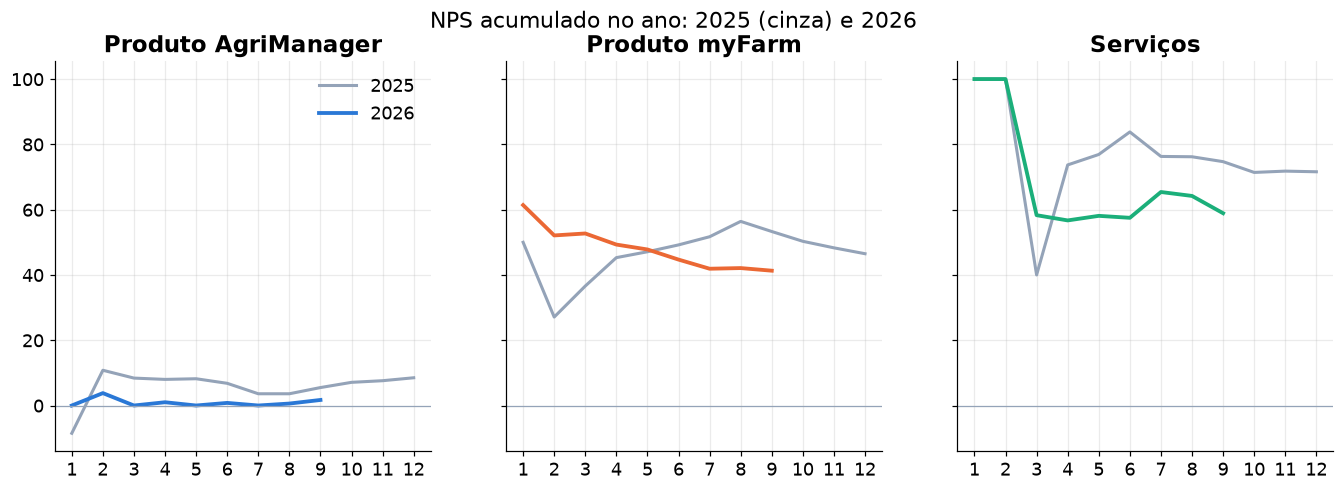

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, g in zip(axs, GRUPOS):
    for a, estilo in ((2025, dict(color=COR_SECUNDARIA, lw=2)), (2026, dict(color=COR[g], lw=2.5))):
        d = acum[(acum["grupo"] == g) & (acum["ano"] == a)]
        ax.plot(d["mes"], d["NPS"], label=str(a), **estilo)
    ax.set_title(g); ax.set_xticks(range(1, 13)); ax.axhline(0, color=COR_SECUNDARIA, lw=0.8)
axs[0].legend(frameon=False); fig.suptitle("NPS acumulado no ano: 2025 (cinza) e 2026"); plt.show()

**Resultado:** o myFarm começou 2026 à frente de 2025 e ficou para trás a partir de junho: a
diferença no acumulado foi de 25 pontos a favor em fevereiro pra 14 contra em agosto. O AgriManager
está abaixo de 2025 desde fevereiro, com distância estável entre 3 e 8 pontos. Serviços oscila pela
base pequena, mas está abaixo de 2025 desde abril.

## A queda do myFarm começou em 2026 ou já vinha de antes?
Mês a mês, o myFarm de 2025 teve um meio de ano muito forte e um fim de ano fraco. Juntar os meses
em blocos mostra em que momento o patamar mudou.

In [27]:
mf = nps[nps["grupo"] == "Produto myFarm"].copy()
blocos = [("jan a mar/25", "2025-01", "2025-03"), ("abr a ago/25", "2025-04", "2025-08"),
          ("set a dez/25", "2025-09", "2025-12"), ("jan a mar/26", "2026-01", "2026-03"), ("abr a set/26", "2026-04", "2026-09")]
pd.DataFrame({nome: calc_nps(mf[(mf["mes"].astype(str) >= a) & (mf["mes"].astype(str) <= b)]) for nome, a, b in blocos}).T[["respostas", "promotores %", "detratores %", "NPS"]]

,respostas,promotores %,detratores %,NPS
jan a mar/25,101.0,62.4,25.7,36.6
abr a ago/25,142.0,81.0,10.6,70.4
set a dez/25,116.0,56.9,31.0,25.9
jan a mar/26,110.0,73.6,20.9,52.7
abr a set/26,171.0,62.0,28.1,33.9


**Resultado:** a queda do myFarm **começou em setembro de 2025**, não em 2026. O patamar
de abril a agosto de 2025 (70, com 81% de promotores) caiu pra 26 de setembro a dezembro de 2025,
voltou a 53 no 1º trimestre de 2026 e caiu de novo pra 34 de abril a setembro. Cada bloco tem de 100
a 170 respostas, então as mudanças são bem maiores que a margem de erro (perto de 8 pontos). O
arquivo não diz a causa; o que acompanha a queda nos comentários é a lentidão (próxima seção).

## O volume de respostas mudou de um ano para o outro?
Menos respostas deixam o acumulado mais sensível a cada nota nova.

In [28]:
vol = nps[nps["data"].dt.month <= 9].groupby(["grupo", "ano"]).size().unstack("ano")
vol.assign(variação=lambda t: (100 * (t[2026] / t[2025] - 1)).round(0).astype(int).astype(str) + "%")

ano,2025,2026,variação
grupo,,,
Produto AgriManager,275,172,-37%
Produto myFarm,272,281,3%
Serviços,75,56,-25%


**Resultado:** de janeiro a setembro, o AgriManager recebeu 37% menos respostas que em
2025 e serviços 25% menos; o myFarm manteve o volume. Menos respostas não mudam o NPS por si, mas
deixam o acumulado mais sensível a cada nota e diminuem o quanto dá pra recuperar até dezembro.
[Suposição] No AgriManager, pode ser menos disparo ou menos usuário ativo; a exportação só traz
quem respondeu, então não dá pra separar.

## Os motivos do detrator mudam entre produto e serviço, e de um ano para o outro?
Mesma conta dos motivos acima, agora por grupo e por ano (janeiro a setembro nos dois anos, pra
comparar o mesmo período).

In [29]:
jas = nps[nps["data"].dt.month <= 9]
dm = jas[(jas["classe"] == "Detrator") & (jas["motivos"].str.len() > 0)]
base_dm = dm.groupby(["grupo", "ano"]).size()
mot = (dm.explode("motivos").groupby(["motivos", "grupo", "ano"]).size() / base_dm * 100).round(0).unstack(["grupo", "ano"]).fillna(0)
mot.loc[mot.sum(axis=1).sort_values(ascending=False).index]

grupo                              Produto AgriManager       Produto myFarm  \
ano                                               2025  2026           2025   
motivos                                                                       
Usabilidade                                        8.0   6.0          100.0   
Outro                                             22.0  32.0            0.0   
Recursos do produto                               44.0  53.0            0.0   
Falhas e estabilidade                             61.0  59.0            0.0   
Planejamento e execução do projeto                 0.0   0.0            0.0   
Relacionamento e outras áreas                     34.0  32.0            0.0   
Suporte                                           37.0  36.0            0.0   
Comunicação                                        0.0   0.0            0.0   
Atendimento do consultor                           0.0   0.0            0.0   
Custo x benefício                                  1.0   2.0            0.0   

grupo                                    Serviços        
ano                                 2026     2025  2026  
motivos                                                  
Usabilidade                         73.0      0.0   0.0  
Outro                                0.0     60.0  60.0  
Recursos do produto                 36.0      0.0  20.0  
Falhas e estabilidade               27.0      0.0   0.0  
Planejamento e execução do projeto   0.0     40.0  60.0  
Relacionamento e outras áreas        0.0      0.0  20.0  
Suporte                              0.0      0.0   0.0  
Comunicação                          0.0     40.0  20.0  
Atendimento do consultor             0.0     20.0   0.0  
Custo x benefício                    0.0      0.0   0.0

In [30]:
base_dm.unstack("ano").rename(columns=lambda a: f"detratores com motivo {a}")

ano,detratores com motivo 2025,detratores com motivo 2026
grupo,,
Produto AgriManager,79,66
Produto myFarm,1,11
Serviços,5,5


In [31]:
cd = jas[jas["classe"] == "Detrator"].explode("temas_coment")
cd = cd[cd["temas_coment"].notna() & (cd["temas_coment"] != "Sem conteúdo")]
cd.groupby(["temas_coment", "grupo", "ano"]).size().unstack(["grupo", "ano"]).fillna(0).astype(int)

grupo                           Produto AgriManager      Produto myFarm       \
ano                                            2025 2026           2025 2026   
temas_coment                                                                   
Aderência ao negócio                              1    0              0    0   
Avaliação genérica                                0    1              1    1   
Elogio ao atendimento                             1    0              0    0   
Evolução do produto                               2    2              0    2   
Falhas e erros de versão                          6    4              2    2   
Lentidão e travamento                             5    1              3   10   
Prazo e condução da implantação                   0    0              0    0   
Relatórios e recursos                             4    3              1    3   
Suporte                                           9    2              0    2   
Usabilidade e complexidade                        3    5              2    3   

grupo                           Serviços       
ano                                 2026 2025  
temas_coment                                   
Aderência ao negócio                   0    0  
Avaliação genérica                     0    0  
Elogio ao atendimento                  0    0  
Evolução do produto                    0    0  
Falhas e erros de versão               1    0  
Lentidão e travamento                  0    0  
Prazo e condução da implantação        1    1  
Relatórios e recursos                  0    1  
Suporte                                0    2  
Usabilidade e complexidade             0    0

**Resultado:** o perfil do detrator do AgriManager é o mesmo de 2025: falhas e
estabilidade em 6 de cada 10, suporte e relacionamento em 1 de cada 3; recursos do produto subiu de
44% pra 53%. No comentário escrito, a queixa de suporte do AgriManager caiu (9 comentários de
detrator de janeiro a setembro de 2025, 2 em 2026) [Provável, base pequena]. No myFarm, **lentidão e
travamento foi de 3 pra 10 comentários de detrator**; os motivos marcados do myFarm não permitem
comparar os anos (1 detrator com motivo em 2025). Serviços tem 5 detratores por ano, base pequena
demais pra ler motivo.

## Onde o acumulado de 2026 deve fechar em dezembro, e supera 2025?
Três cenários para outubro a dezembro, todos com o volume de respostas do 3º trimestre de 2026:
o mesmo NPS do 3º trimestre de 2026 (ritmo atual), o NPS do 4º trimestre de 2025 (o que o fim do
ano costuma trazer) e o melhor trimestre de 2026. Ao lado, o NPS que o 4º trimestre precisaria ter
para o ano fechar acima de 2025.

In [32]:
def projecao(g):
    d26 = n26[n26["grupo"] == g]; d25 = n25[n25["grupo"] == g]
    n0 = len(d26); liq0 = (d26["classe"] == "Promotor").sum() - (d26["classe"] == "Detrator").sum()
    q3 = d26[d26["data"].dt.quarter == 3]; resto = len(q3)
    cen = {"ritmo do 3º tri/26": calc_nps(q3)["NPS"],
           "repete o 4º tri/25": calc_nps(d25[d25["data"].dt.quarter == 4])["NPS"],
           "melhor tri de 2026": max(calc_nps(d26[d26["data"].dt.quarter == q])["NPS"] for q in (1, 2, 3))}
    fim = {f"dez · {k}": round(100 * (liq0 + s / 100 * resto) / (n0 + resto), 1) for k, s in cen.items()}
    alvo = META.loc[g, "NPS"]
    precisa = round(100 * (alvo / 100 * (n0 + resto) - liq0) / resto, 1)
    return pd.Series({"set/26": round(100 * liq0 / n0, 1), "meta (2025)": alvo, "respostas out a dez": resto,
                      **{f"NPS do cenário · {k}": s for k, s in cen.items()}, **fim, "4º tri precisaria": precisa})

proj = pd.DataFrame({g: projecao(g) for g in GRUPOS}).T
proj

,set/26,meta (2025),respostas out a dez,NPS do cenário · ritmo do 3º tri/26,NPS do cenário · repete o 4º tri/25,NPS do cenário · melhor tri de 2026,dez · ritmo do 3º tri/26,dez · repete o 4º tri/25,dez · melhor tri de 2026,4º tri precisaria
Produto AgriManager,1.7,8.5,39.0,5.1,20.6,5.1,2.4,5.2,2.4,38.3
Produto myFarm,41.3,46.5,73.0,31.5,25.3,52.7,39.3,38.0,43.6,66.6
Serviços,58.9,71.6,16.0,62.5,33.3,62.5,59.7,53.2,59.7,116.0


Quanta incerteza cabe nisso? Simulação com o ritmo do 3º trimestre de 2026: o volume de
outubro a dezembro varia em torno do volume do 3º trimestre, e a divisão entre promotores, neutros
e detratores varia em torno da divisão observada no 3º trimestre.

In [33]:
rng = np.random.default_rng(2026)

def simula(g, sims=20000):
    d26 = n26[n26["grupo"] == g]; q3 = d26[d26["data"].dt.quarter == 3]
    n0 = len(d26); liq0 = (d26["classe"] == "Promotor").sum() - (d26["classe"] == "Detrator").sum()
    cont = np.array([(q3["classe"] == c).sum() for c in ("Promotor", "Neutro", "Detrator")]) + 1
    vol = rng.poisson(len(q3), sims)
    x = np.array([rng.multinomial(v, p) for v, p in zip(vol, rng.dirichlet(cont, sims))])
    final = 100 * (liq0 + x[:, 0] - x[:, 2]) / (n0 + vol)
    return pd.Series({"chance de superar 2025 %": round(100 * (final > META.loc[g, "NPS"]).mean(), 1),
                      "dez · 10% pior": round(np.percentile(final, 10), 1),
                      "dez · mediana": round(np.percentile(final, 50), 1),
                      "dez · 10% melhor": round(np.percentile(final, 90), 1)})

sim = pd.DataFrame({g: simula(g) for g in GRUPOS}).T
sim

,chance de superar 2025 %,dez · 10% pior,dez · mediana,dez · 10% melhor
Produto AgriManager,4.4,-2.4,2.3,7.0
Produto myFarm,0.3,35.1,39.1,42.8
Serviços,0.0,50.7,58.0,63.5


**Resultado:** **nenhum dos três fecha 2026 acima de 2025 em nenhum dos cenários.**
- AgriManager: o melhor cenário (repetir o 4º trimestre de 2025) leva a 5; pra passar de 8,5,
  outubro a dezembro precisariam de NPS 38, e o melhor trimestre de 2026 foi 5.
- myFarm: o melhor cenário (repetir o 1º trimestre de 2026) leva a 44; seria preciso 67 no 4º
  trimestre, acima de qualquer trimestre dos dois anos (o melhor foi 65, no 2º trimestre de 2025).
- Serviços: a conta não fecha nem com 100% de promotores; com o volume atual, o 4º trimestre teria
  que ter mais promotores líquidos do que respostas.

A simulação confirma: chance de 4% no AgriManager e abaixo de 1% nos outros dois. [Provável] Isso só
muda se o volume de respostas crescer muito, e com nota alta, o que não aparece em nenhum mês de 2026.

# Parte 3 · Qual é o motivo real de cada nota?
As colunas de motivo e o comentário contam partes diferentes da história. Esta parte olha as duas
fontes e define um **motivo principal por resposta**: o comentário manda quando diz o porquê; sem
comentário útil, vale o motivo marcado (na ordem de prioridade do grupo e da classe); "Outro"
sozinho não conta como motivo. A regra completa está em `motivo_real.py`.

## As opções de motivo mudam conforme a nota?
No AgriManager, o cliente escolhe o motivo numa lista. Contar cada opção por classe mostra se a
lista é a mesma para todo mundo.

In [34]:
agm_op = nps[nps["grupo"] == "Produto AgriManager"].explode("marcado_cliente").dropna(subset=["marcado_cliente"]).reset_index(drop=True)
pd.crosstab(agm_op["marcado_cliente"], agm_op["classe"])

classe,Detrator,Neutro,Promotor
marcado_cliente,,,
Aderência do ERP ao seu Negócio,0,0,112
Aderência do ERP ao seu dia a dia,0,36,0
Atendimento do Suporte Aliare,61,0,0
Atualização de versão do ERP,37,0,0
Experiência com o Suporte Aliare,0,30,77
Experiência com outras áreas Aliare,0,0,33
Falhas durante o uso do ERP,86,0,0
Falta de Contato,31,0,0
Outro,44,28,34


**Resultado:** [Certo] a lista de motivos **muda conforme a nota**. Quem dá de 0 a 6 só vê
opções negativas (falhas, recursos, atendimento do suporte, atualização de versão, falta de contato);
quem dá 7 ou 8 vê usabilidade, aderência ao dia a dia e suporte; quem dá 9 ou 10 vê aderência ao
negócio, suporte e outras áreas. Por isso "usabilidade" só aparece entre neutros e "falhas" só entre
detratores: é o cardápio da pesquisa, não uma descoberta. O motivo marcado só compara dentro da
mesma classe, e a comparação útil é de um ano para o outro dentro da classe.

## Quando o cliente marca motivo e também escreve, as duas coisas contam a mesma história?
Só entram as respostas que têm as duas coisas: um comentário que diz o porquê e um motivo marcado
diferente de "Outro".

In [35]:
nps["mot_coment"] = [do_comentario(i, t, c, g) for i, t, c, g in zip(nps["id"], nps["temas_coment"], nps["classe"], nps["grupo"])]
nps["mot_marcado"] = [do_marcado(m, c, g) for m, c, g in zip(nps["marcados"], nps["classe"], nps["grupo"])]
nps["cats_marcadas"] = nps["marcados"].map(lambda l: {MARCADO[m] for m in l if m in MARCADO})
ambos = nps[nps["mot_coment"].notna() & nps["mot_marcado"].notna()].copy()
ambos["bate"] = [c in s for c, s in zip(ambos["mot_coment"], ambos["cats_marcadas"])]
ambos.groupby("grupo")["bate"].agg(respostas="size", batem="sum").assign(**{"% que batem": lambda t: (100 * t["batem"] / t["respostas"]).round(0)})

,respostas,batem,% que batem
grupo,,,
Produto AgriManager,57,39,68.0
Produto myFarm,27,11,41.0
Serviços,79,72,91.0


In [36]:
ambos[~ambos["bate"]].groupby(["mot_marcado", "mot_coment"]).size().sort_values(ascending=False).head(10).to_frame("respostas")

respostas
mot_marcado                 mot_coment                                
Facilidade de uso           Lentidão e quedas do sistema            11
Erros e falhas do sistema   Lentidão e quedas do sistema             6
Facilidade de uso           Erros e falhas do sistema                2
Relacionamento com a Aliare Suporte                                  2
Recursos e relatórios       Evolução e melhorias do produto          2
                            Erros e falhas do sistema                2
Atendimento do consultor    Condução da implantação                  2
Recursos e relatórios       Facilidade de uso                        2
Erros e falhas do sistema   Evolução e melhorias do produto          2
Aderência ao negócio        Lentidão e quedas do sistema             1

**Resultado:** em serviços o motivo marcado e o comentário contam a mesma história em 9 de
cada 10 casos; no AgriManager, em 7 de cada 10. **No myFarm, só em 4 de cada 10.** O desencontro mais
comum, somando os grupos, é a tratativa registrar "usabilidade" ou "falhas" quando o cliente escreveu
sobre lentidão (17 casos). É por isso que o motivo real usa o comentário primeiro.

## O que diz quem marca só "Outro"?

In [37]:
so_outro = nps[nps["marcados"].map(lambda l: l == ["Outro"])]
so_outro.groupby(["grupo", "ano"]).agg(respostas=("id", "size"), com_comentario=("tem_texto", "sum"))

respostas  com_comentario
grupo               ano                            
Produto AgriManager 2025         11               3
                    2026          9               1
Serviços            2025          4               3
                    2026         20               2

In [38]:
so_outro[so_outro["mot_coment"].notna()]["mot_coment"].value_counts().to_frame("motivo lido no comentário")

,motivo lido no comentário
mot_coment,
Aderência ao negócio,2
Erros e falhas do sistema,2
Lentidão e quedas do sistema,1
Facilidade de uso,1
Suporte,1
Condução da implantação,1


**Resultado:** marcar só "Outro" (sem nenhuma categoria de tratativa) é raro no produto,
mas em serviços de 2026 são 20 respostas, e só 2 com comentário. Nessas, o motivo fica em branco. É
uma perda de informação nova de 2026 em serviços: em 2025 eram 4.

## Qual é o motivo real da nota em 2026, por grupo e classe?
Fatia sobre as respostas que informaram algum motivo; ao lado, quantas não informaram.

In [39]:
def tabela_motivo(df):
    inf = df[df["motivo_real"] != SEM]
    t = (inf.groupby(["grupo", "motivo_real"]).size() / inf.groupby("grupo").size() * 100).round(0).unstack("grupo").fillna(0)
    base = pd.DataFrame({"informaram": inf.groupby("grupo").size(), "total": df.groupby("grupo").size()}).T
    return t.loc[t.sum(axis=1).sort_values(ascending=False).index], base

t_det, b_det = tabela_motivo(n26[n26["classe"] == "Detrator"])
b_det

grupo,Produto AgriManager,Produto myFarm,Serviços
informaram,66,16,4
total,66,71,5


In [40]:
t_det

grupo,Produto AgriManager,Produto myFarm,Serviços
motivo_real,,,
Erros e falhas do sistema,53.0,6.0,25.0
Condução da implantação,0.0,0.0,75.0
Lentidão e quedas do sistema,2.0,56.0,0.0
Recursos e relatórios,26.0,6.0,0.0
Suporte,9.0,12.0,0.0
Evolução e melhorias do produto,3.0,12.0,0.0
Facilidade de uso,6.0,6.0,0.0
Relacionamento com a Aliare,2.0,0.0,0.0


In [41]:
t_pro, b_pro = tabela_motivo(n26[n26["classe"] == "Promotor"])
pd.concat([b_pro, t_pro])

grupo,Produto AgriManager,Produto myFarm,Serviços
informaram,62.0,4.0,23.0
total,69.0,187.0,38.0
Aderência ao negócio,76.0,50.0,4.0
Atendimento do consultor,0.0,0.0,87.0
Facilidade de uso,3.0,25.0,0.0
Recursos e relatórios,0.0,25.0,0.0
Suporte,16.0,0.0,0.0
Condução da implantação,0.0,0.0,9.0
Relacionamento com a Aliare,5.0,0.0,0.0


**Resultado:** com um motivo principal por resposta, a leitura fica direta. **No AgriManager,
o detrator sai por erros e falhas do sistema (metade) e por falta de recursos e relatórios (um em
cada quatro)**; o promotor fica pela aderência ao negócio (três em cada quatro). **No myFarm, dos 71
detratores de 2026, só 16 dizem o porquê, e 9 deles falam de lentidão e quedas do sistema.** Em
serviços, o promotor elogia o consultor (quase 9 em cada 10) e os poucos detratores reclamam da
condução da implantação. No myFarm, 183 de 187 promotores não dizem por que gostam; não dá para
tirar motivo de promotor ali.

## O motivo real do detrator mudou de 2025 para 2026?
Janeiro a setembro nos dois anos, para comparar o mesmo período.

In [42]:
jas = nps[nps["data"].dt.month <= 9]
dj = jas[(jas["classe"] == "Detrator") & (jas["motivo_real"] != SEM)]
mr = (dj.groupby(["grupo", "ano", "motivo_real"]).size() / dj.groupby(["grupo", "ano"]).size() * 100).round(0).unstack(["grupo", "ano"]).fillna(0)
mr.loc[mr.sum(axis=1).sort_values(ascending=False).index]

grupo                           Produto AgriManager       Produto myFarm  \
ano                                            2025  2026           2025   
motivo_real                                                                
Erros e falhas do sistema                      55.0  53.0           25.0   
Condução da implantação                         0.0   0.0            0.0   
Lentidão e quedas do sistema                    5.0   2.0           38.0   
Suporte                                        13.0   9.0            0.0   
Recursos e relatórios                          19.0  26.0            0.0   
Facilidade de uso                               3.0   6.0           25.0   
Evolução e melhorias do produto                 1.0   3.0            0.0   
Aderência ao negócio                            1.0   0.0           12.0   
Relacionamento com a Aliare                     3.0   2.0            0.0   

grupo                                 Serviços        
ano                              2026     2025  2026  
motivo_real                                           
Erros e falhas do sistema         6.0      0.0  25.0  
Condução da implantação           0.0     60.0  75.0  
Lentidão e quedas do sistema     56.0      0.0   0.0  
Suporte                          12.0     40.0   0.0  
Recursos e relatórios             6.0      0.0   0.0  
Facilidade de uso                 6.0      0.0   0.0  
Evolução e melhorias do produto  12.0      0.0   0.0  
Aderência ao negócio              0.0      0.0   0.0  
Relacionamento com a Aliare       0.0      0.0   0.0

In [43]:
pd.DataFrame({"detratores": jas[jas["classe"] == "Detrator"].groupby(["grupo", "ano"]).size(),
              "informaram motivo": dj.groupby(["grupo", "ano"]).size()})

detratores  informaram motivo
grupo               ano                                
Produto AgriManager 2025          93                 77
                    2026          66                 66
Produto myFarm      2025          49                  8
                    2026          71                 16
Serviços            2025           5                  5
                    2026           5                  4

**Resultado:** o detrator do AgriManager tem o mesmo perfil nos dois anos (erros e falhas
em pouco mais da metade), com recursos e relatórios subindo de 19% para 26% e suporte caindo de 13%
para 9% [Provável, diferenças perto da margem]. No myFarm, a lentidão foi de 3 de 8 detratores que
disseram o motivo em 2025 para 9 de 16 em 2026; a base é pequena, mas vai na mesma direção dos
comentários. Serviços tem 5 detratores por ano, sem base para comparar.

# Parte 4 · O que vai bem em 2026
Pontos positivos de 2026 para a visão geral: quem melhorou a nota e o que o cliente diz do
acompanhamento.

## Que clientes foram de detrator a promotor dentro de 2026?
Por conta, primeira e última resposta de 2026: a primeira de detrator (0 a 6) e a última de
promotor (9 ou 10).

In [44]:
o26 = n26.sort_values("data")
ev26 = o26.groupby(["grupo", "cliente"]).agg(respostas=("nota", "size"), primeira=("nota", "first"), ultima=("nota", "last"),
                                              de=("data", "first"), ate=("data", "last"), conta=("conta", "last"))
viraram = ev26[(ev26["primeira"] <= 6) & (ev26["ultima"] >= 9) & (ev26["de"] < ev26["ate"])]
viraram.assign(de=viraram["de"].dt.strftime("%d/%m"), ate=viraram["ate"].dt.strftime("%d/%m")).sort_values("primeira")

respostas  primeira  ultima  \
grupo               cliente                                                    
Produto AgriManager CONDOMINIO ITAGUASSU                 3         0      10   
Produto myFarm      FABRICIO KRZYZANSKI                  2         2      10   
                    GABRIEL CARRIJO CARVALHO             3         5      10   
                    CLEONESIO LUIZ MARX                  2         5       9   
                    JANETE MISSIO                        2         5      10   
                    ROBERTO NUNES MEDINA COELI           3         5       9   
Produto AgriManager FERNANDO CAVALHEIRO MACHADO          3         6      10   
                    BINOTTI SEEDS LTDA                   2         6      10   

                                                    de    ate  \
grupo               cliente                                     
Produto AgriManager CONDOMINIO ITAGUASSU         18/02  02/09   
Produto myFarm      FABRICIO KRZYZANSKI          13/01  01/04   
                    GABRIEL CARRIJO CARVALHO     23/02  17/08   
                    CLEONESIO LUIZ MARX          26/02  26/06   
                    JANETE MISSIO                03/02  21/06   
                    ROBERTO NUNES MEDINA COELI   02/01  07/07   
Produto AgriManager FERNANDO CAVALHEIRO MACHADO  28/04  17/09   
                    BINOTTI SEEDS LTDA           06/04  10/08   

                                                                       conta  
grupo               cliente                                                   
Produto AgriManager CONDOMINIO ITAGUASSU                CONDOMINIO ITAGUASSU  
Produto myFarm      FABRICIO KRZYZANSKI                  Fabricio Krzyzanski  
                    GABRIEL CARRIJO CARVALHO        Gabriel Carrijo Carvalho  
                    CLEONESIO LUIZ MARX                  CLEONESIO LUIZ MARX  
                    JANETE MISSIO                              Janete Missio  
                    ROBERTO NUNES MEDINA COELI    Roberto Nunes Medina Coeli  
Produto AgriManager FERNANDO CAVALHEIRO MACHADO  FERNANDO CAVALHEIRO MACHADO  
                    BINOTTI SEEDS LTDA                    BINOTTI SEEDS LTDA

## Quantos respondentes passaram a promotores em 2026?
A Track guarda a nota anterior de quem já tinha respondido. Conta quem vinha de detrator ou neutro
e em 2026 deu 9 ou 10, e também o movimento contrário, para ter a foto inteira.

In [45]:
na = n26[n26["nota_anterior"].notna()]
pd.Series({"respondentes com nota anterior": len(na),
           "passaram a promotor (vinham de detrator)": int(((na["nota"] >= 9) & (na["nota_anterior"] <= 6)).sum()),
           "passaram a promotor (vinham de neutro)": int(((na["nota"] >= 9) & na["nota_anterior"].between(7, 8)).sum()),
           "subiram a nota": int((na["nota"] > na["nota_anterior"]).sum()),
           "mantiveram": int((na["nota"] == na["nota_anterior"]).sum()),
           "baixaram": int((na["nota"] < na["nota_anterior"]).sum())}).to_frame("respondentes")

,respondentes
respondentes com nota anterior,287
passaram a promotor (vinham de detrator),17
passaram a promotor (vinham de neutro),15
subiram a nota,64
mantiveram,148
baixaram,75


## O que o cliente escreve sobre o acompanhamento?
Comentários de 2026 com elogio ao atendimento, ao suporte ou ao CS.

In [46]:
elogio = n26[n26["tem_texto"] & n26["temas_coment"].map(lambda t: "Elogio ao atendimento" in t or "Suporte" in t) & (n26["classe"] != "Detrator")]
elogio[["grupo", "conta", "nota", "data", "comentario"]].sort_values("nota", ascending=False).head(8)

,grupo,conta,nota,data,comentario
1242,Serviços,FAZENDAS LR KONAGESKI - DIAMANTINO-MT,10,2026-07-21 16:40:00,"RECOMENDO ELE SEMPRE, MUIITO PRESTATIVO, NAO T..."
1246,Serviços,GRUPO CATELAN - LUIS EDUARDO MAGALHAES-BA,10,2026-07-13 10:04:00,FOI MUITO BOM
1243,Serviços,AGRO LOPEI S.A -CASCAVEL- PR,10,2026-07-21 16:37:00,"MUITO GENTE FINA, MUITO BOM O TRABALHO DELE."
1285,Serviços,GRUPO CATELAN - LUIS EDUARDO MAGALHAES-BA,10,2026-03-09 17:36:00,Foi muito bom pode aproveitar com clareza na e...
1288,Serviços,FAZENDAS LR KONAGESKI - DIAMANTINO-MT,10,2026-03-09 16:55:00,"Leonardo ele é muito didatico, muito atencioso..."
1265,Serviços,FERNANDO DOTTO - SANTANA DO ARAGUAIA-PA,10,2026-04-20 16:36:00,"recomendaria com certeza, ele foi muito presta..."
1248,Serviços,FAZENDA CANAA - AGUA BOA - MT,10,2026-07-09 10:49:00,"DEU TUDO CERTO, MUITO TRANQUILO, MUITO BOM."
1278,Serviços,MBB AGRO - SAO FELIX DE BALSAS-MA,10,2026-04-06 14:54:00,"NOTA 20, LEONARDO MUITO BOM. DESEJO UM DIA CON..."


**Resultado:** há boas histórias em 2026. Oito contas foram de detrator a promotor dentro do
ano, entre elas o Condomínio Itaguassu (a mesma usuária foi de 5 em março para 10 em setembro,
apontando o suporte) e, no myFarm, a conta de Fabricio Krzyzanski (de 2 em janeiro para 10 em abril).
O Condomínio Bigolin também melhorou: reclamação de falta de suporte em abril, só notas 10 em junho. Pela nota
anterior, 32 respondentes que davam nota de detrator ou neutro passaram a promotores. Para ter a foto
inteira: entre os 287 que já tinham nota anterior, 64 subiram e 75 baixaram, então o saldo individual
ainda é levemente negativo; os destaques são reais, mas não compensam sozinhos a queda do myFarm.
No texto, o cliente reconhece o acompanhamento: "a equipe de Sucesso do Cliente está mais próxima,
atenta às nossas necessidades" (Parceria Agrícola S EPP Nova, nota 9).

## Exportar a base pra apresentação
A página lê este JSON embutido; os filtros de tela recalculam tudo a partir das respostas. O
`resumo-nps.json` leva os números citados no texto da visão geral.

In [47]:
saida = nps.assign(data=nps["data"].dt.strftime("%Y-%m-%d"), mes=nps["mes"].astype(str))
cols = ["id", "ano", "grupo", "campanha", "linha", "data", "mes", "nota", "nota_anterior", "classe", "conta", "cliente",
        "respondente", "uf", "status_painel", "comentario", "tem_texto", "marcados", "motivo_real"]
registros = json.loads(saida[cols].to_json(orient="records", force_ascii=False))
json.dump(registros, open("dados-nps.json", "w", encoding="utf-8"), ensure_ascii=False)
len(registros)

1292

In [48]:
def f(v):
    v = int(np.floor(float(v) + 0.5))  # mesmo arredondamento da página (Math.round)
    return ("−" + str(abs(v))) if v < 0 else str(v)

tri = n26.groupby(["grupo", "tri"])[["classe"]].apply(calc_nps)["NPS"]
cls = lambda g, c: (n26[(n26["grupo"] == g)]["classe"] == c).mean() * 100
dq = lambda g, q: n26[(n26["grupo"] == g) & (n26["tri"] == q)]
pq = lambda g, q, c: (dq(g, q)["classe"] == c).mean() * 100
detm = n26[(n26["classe"] == "Detrator") & (n26["motivos"].str.len() > 0)]
share = lambda g, m: 100 * detm[detm["grupo"] == g]["motivos"].map(lambda l: m in l).mean()
com26 = n26[n26["comentario"].notna() & n26["temas_coment"].map(lambda t: t != ["Sem conteúdo"])]
detr = n26[n26["classe"] == "Detrator"]
resumo = {
    "agm_hoje": f(hoje.loc["Produto AgriManager", "NPS"]), "mf_hoje": f(hoje.loc["Produto myFarm", "NPS"]),
    "sv_hoje": f(hoje.loc["Serviços", "NPS"]),
    "agm_set25": f(set25.loc["Produto AgriManager", "NPS"]), "mf_set25": f(set25.loc["Produto myFarm", "NPS"]),
    "sv_set25": f(set25.loc["Serviços", "NPS"]),
    "mf_t1": f(tri[("Produto myFarm", "T1")]), "mf_t2": f(tri[("Produto myFarm", "T2")]), "mf_t3": f(tri[("Produto myFarm", "T3")]),
    "mf_queda_tri": f(tri[("Produto myFarm", "T1")] - tri[("Produto myFarm", "T3")]),
    "mf_pro_t1": f(pq("Produto myFarm", "T1", "Promotor")), "mf_pro_t3": f(pq("Produto myFarm", "T3", "Promotor")),
    "mf_det_t1": f(pq("Produto myFarm", "T1", "Detrator")), "mf_det_t3": f(pq("Produto myFarm", "T3", "Detrator")),
    "mf_det_coment": str(len(com26[(com26["grupo"] == "Produto myFarm") & (com26["classe"] == "Detrator")])),
    "mf_det_lentidao": str(com26[(com26["grupo"] == "Produto myFarm") & (com26["classe"] == "Detrator")]["temas_coment"].map(lambda t: "Lentidão e travamento" in t).sum()),
    "agm_t1": f(tri[("Produto AgriManager", "T1")]), "agm_t2": f(tri[("Produto AgriManager", "T2")]), "agm_t3": f(tri[("Produto AgriManager", "T3")]),
    "agm_det_pct": f(cls("Produto AgriManager", "Detrator")),
    "agm_falhas": f(share("Produto AgriManager", "Falhas e estabilidade")), "agm_recursos": f(share("Produto AgriManager", "Recursos do produto")),
    "sv_coment": str(len(com26[com26["grupo"] == "Serviços"])),
    "sv_elogio": str(com26[com26["grupo"] == "Serviços"]["temas_coment"].map(lambda t: "Elogio ao atendimento" in t).sum()),
    "det_total": str(len(detr)),
    "det_semcontato": str((detr["status"] == "Encerrado sem sucesso nos contatos").sum()),
    "det_pendente": str(detr["status"].isin(["Pendente Atuacao", "Pendente Atuacao Siagri", "Pendente Aguardando Cliente"]).sum()),
    "det_resolvido": str((detr["status"] == "Resolvido Satisfeito").sum()),
    **{f"{k}_chance": f(sim.loc[g, "chance de superar 2025 %"]) for k, g in (("agm", "Produto AgriManager"), ("mf", "Produto myFarm"), ("sv", "Serviços"))},
    **{f"{k}_precisa": f(proj.loc[g, "4º tri precisaria"]) for k, g in (("agm", "Produto AgriManager"), ("mf", "Produto myFarm"), ("sv", "Serviços"))},
    **{f"{k}_meta": f"{META.loc[g, 'NPS']:.1f}".replace(".", ",") for k, g in (("agm", "Produto AgriManager"), ("mf", "Produto myFarm"), ("sv", "Serviços"))},
}
resumo["det_semretorno"] = str(int(resumo["det_semcontato"]) + int(resumo["det_pendente"]))
for k, g in (("agm", "Produto AgriManager"), ("mf", "Produto myFarm"), ("sv", "Serviços")):
    resumo[f"{k}_dif"] = f(abs(hoje.loc[g, "NPS"] - set25.loc[g, "NPS"]))
    resumo[f"{k}_vol"] = f(abs(100 * (vol.loc[g, 2026] / vol.loc[g, 2025] - 1)))
blk = {nome: calc_nps(mf[(mf["mes"].astype(str) >= a) & (mf["mes"].astype(str) <= b)])["NPS"] for nome, a, b in blocos}
resumo.update({"mf_b2": f(blk["abr a ago/25"]), "mf_b3": f(blk["set a dez/25"]), "mf_b4": f(blk["jan a mar/26"]), "mf_b5": f(blk["abr a set/26"])})
resumo["mf_det_lentidao25"] = str(cd[(cd["grupo"] == "Produto myFarm") & (cd["ano"] == 2025) & (cd["temas_coment"] == "Lentidão e travamento")].shape[0])
# motivo real do detrator, janeiro a setembro de cada ano
cont_mr = dj.groupby(["grupo", "ano", "motivo_real"]).size()
inf_mr = dj.groupby(["grupo", "ano"]).size()
pct_mr = lambda g, a, m: 100 * cont_mr.get((g, a, m), 0) / inf_mr.get((g, a), 1)
resumo.update({
    "agm_mr_falhas26": f(pct_mr("Produto AgriManager", 2026, "Erros e falhas do sistema")),
    "agm_mr_recursos26": f(pct_mr("Produto AgriManager", 2026, "Recursos e relatórios")),
    "agm_mr_falhas25": f(pct_mr("Produto AgriManager", 2025, "Erros e falhas do sistema")),
    "agm_mr_recursos25": f(pct_mr("Produto AgriManager", 2025, "Recursos e relatórios")),
    "mf_det26": str(len(jas[(jas["grupo"] == "Produto myFarm") & (jas["ano"] == 2026) & (jas["classe"] == "Detrator")])),
    "mf_inf26": str(inf_mr.get(("Produto myFarm", 2026), 0)),
    "mf_lent26": str(cont_mr.get(("Produto myFarm", 2026, "Lentidão e quedas do sistema"), 0)),
    "mf_inf25": str(inf_mr.get(("Produto myFarm", 2025), 0)),
    "mf_lent25": str(cont_mr.get(("Produto myFarm", 2025, "Lentidão e quedas do sistema"), 0)),
})
# destaques positivos de 2026
NOME_MES = ["janeiro", "fevereiro", "março", "abril", "maio", "junho", "julho", "agosto", "setembro", "outubro", "novembro", "dezembro"]
mes_mf = n26[n26["grupo"] == "Produto myFarm"].groupby(n26["data"].dt.month)[["classe"]].apply(calc_nps)
mes_mf = mes_mf[mes_mf["respostas"] >= 10].sort_values("NPS", ascending=False)
pro_inf = n26[(n26["classe"] == "Promotor") & (n26["motivo_real"] != SEM)]
fatia_pro = lambda g, m: 100 * (pro_inf[pro_inf["grupo"] == g]["motivo_real"] == m).mean()
resumo.update({
    "sv_pro": f(hoje.loc["Serviços", "promotores %"]), "mf_pro": f(hoje.loc["Produto myFarm", "promotores %"]),
    "agm_pro": f(hoje.loc["Produto AgriManager", "promotores %"]),
    "mf_pro_n": str(int((n26[n26["grupo"] == "Produto myFarm"]["classe"] == "Promotor").sum())),
    "mf_n": str(int((n26["grupo"] == "Produto myFarm").sum())),
    "mf_best_mes": NOME_MES[int(mes_mf.index[0]) - 1], "mf_best": f(mes_mf.iloc[0]["NPS"]),
    "det_tratado": str(int(dt["status_painel"].isin(TRATADO).sum())),
    "agm_pro_ader": f(fatia_pro("Produto AgriManager", "Aderência ao negócio")),
    "sv_pro_cons": f(fatia_pro("Serviços", "Atendimento do consultor")),
    "promovidos": str(int(((na["nota"] >= 9) & (na["nota_anterior"] <= 8)).sum())),
    "viraram_n": str(len(viraram)),
})
import html as _html
ABREV = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
nome_bonito = lambda s: s.title() if s.isupper() else s
itens_v = viraram.reset_index().sort_values(["primeira", "ultima"], ascending=[True, False])
resumo["viraram_html"] = "".join(
    f'<li><span class="vg"><i class="sw" style="background:var(--{ {"Produto AgriManager": "s1", "Produto myFarm": "s2", "Serviços": "s3"}[r.grupo] })"></i>{_html.escape(r.grupo)}</span>'
    f'<b>{_html.escape(nome_bonito(r.conta))}</b><span class="vn">{r.primeira} → {r.ultima}</span>'
    f'<span class="vd">{ABREV[r.de.month - 1]} a {ABREV[r.ate.month - 1]}</span></li>'
    for r in itens_v.itertuples())
json.dump(resumo, open("resumo-nps.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
json.dump(resumo, open("resumo-nps.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
resumo

{'agm_hoje': '2',
 'mf_hoje': '41',
 'sv_hoje': '59',
 'agm_set25': '6',
 'mf_set25': '53',
 'sv_set25': '75',
 'mf_t1': '53',
 'mf_t2': '36',
 'mf_t3': '32',
 'mf_queda_tri': '21',
 'mf_pro_t1': '74',
 'mf_pro_t3': '60',
 'mf_det_t1': '21',
 'mf_det_t3': '29',
 'mf_det_coment': '17',
 'mf_det_lentidao': '10',
 'agm_t1': '0',
 'agm_t2': '2',
 'agm_t3': '5',
 'agm_det_pct': '38',
 'agm_falhas': '59',
 'agm_recursos': '53',
 'sv_coment': '27',
 'sv_elogio': '18',
 'det_total': '142',
 'det_semcontato': '46',
 'det_pendente': '51',
 'det_resolvido': '5',
 'agm_chance': '4',
 'mf_chance': '0',
 'sv_chance': '0',
 'agm_precisa': '38',
 'mf_precisa': '67',
 'sv_precisa': '116',
 'agm_meta': '8,5',
 'mf_meta': '46,5',
 'sv_meta': '71,6',
 'det_semretorno': '97',
 'agm_dif': '4',
 'agm_vol': '37',
 'mf_dif': '12',
 'mf_vol': '3',
 'sv_dif': '16',
 'sv_vol': '25',
 'mf_b2': '70',
 'mf_b3': '26',
 'mf_b4': '53',
 'mf_b5': '34',
 'mf_det_lentidao25': '3',
 'agm_mr_falhas26': '53',
 'agm_mr_recurs

## Resumo
- **NPS acumulado em setembro de 2026:** serviços 59 no arquivo (62 na Track), myFarm 41, AgriManager 2.
- **Contra 2025 no mesmo ponto:** os três abaixo (AgriManager 4 pontos, myFarm 12, serviços 16).
- **myFarm:** a queda começou em setembro de 2025 (de 70 pra 26), teve alívio no 1º trimestre de
  2026 (53) e voltou a 34 de abril a setembro; lentidão e travamento dominam o comentário do detrator.
- **AgriManager:** perto de zero o ano todo, mesmo perfil de detrator de 2025 (falhas, recursos,
  suporte), com 37% menos respostas.
- **Serviços:** maior NPS da operação, sustentado pelo consultor; a crítica é a condução da implantação.
- **Meta (superar 2025 em cada grupo):** nenhum grupo chega lá em nenhum cenário; AgriManager
  precisaria de NPS 38 e myFarm de 67 de outubro a dezembro.
- **Motivo real (um por resposta, comentário primeiro):** AgriManager perde por erros e falhas do
  sistema e por falta de recursos; myFarm por lentidão e quedas, mas só 16 de 71 detratores dizem o
  porquê; serviços ganha pelo consultor e perde pela condução da implantação. A lista de motivos da
  pesquisa muda conforme a nota, então motivo só se compara dentro da mesma classe.
- **Acompanhamento:** 85 de 142 detratores de 2026 tratados pelo CS (os 51 pendentes da Track já
  foram tratados, confirmado pelo Julio em 29/09/2026); em 46 o cliente não atendeu às tentativas de
  contato. Oito contas foram de detrator a promotor dentro de 2026.

A apresentação `NPS 2026.html` lê `dados-nps.json` e `resumo-nps.json` e recalcula tudo pelos
filtros de tela.